# Cyber Threats & Macroeconomics: Hypothesis Testing

This notebook conducts formal statistical tests to validate the insights and trends discovered during the Exploratory Data Analysis (EDA) phase. 

We will be testing two specific hypotheses regarding how geopolitical stability and economic crises impact the frequency and motivation of cyber attacks.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings

# Visual settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
df = pd.read_csv('../datasets/processed/processed_cyber_data.csv')
df['year'] = df['year'].fillna(0).astype(int)

# Create the cleaned columns
df['motive_clean'] = (
    df['motive']
    .fillna('Unknown')
    .astype(str)
    .str.split(';')
    .apply(lambda x: x[0].strip() if len(x) > 0 else 'Unknown')
)

print("Data loaded successfully. Ready for Hypothesis Testing.")

Data loaded successfully. Ready for Hypothesis Testing.


---
## Hypothesis 1: Political Stability Shock (Paired T-Test)

We observed in the EDA that sudden drops in a country's political stability score seemed to trigger a spike in hacktivism and digital protests. We will use a Paired T-Test to determine if this increase is statistically significant.

* **H₀ (Null Hypothesis):** The average number of "Protest" motivated attacks is the **same** the year before vs. the year of a sudden drop in a country’s "Political Stability" score.
* **Hₐ (Alternative Hypothesis):** The average number of "Protest" motivated attacks is **greater** in the year of a stability drop.
* **Method:** Paired T-Test (comparing the "before" and "after" states of the exact same countries).

Results for Paired T-Test (n=387 shocks):
T-Statistic: 0.5429
P-Value:     2.9377e-01

Conclusion: FAIL TO REJECT H₀. The increase is not statistically significant at alpha=0.05.


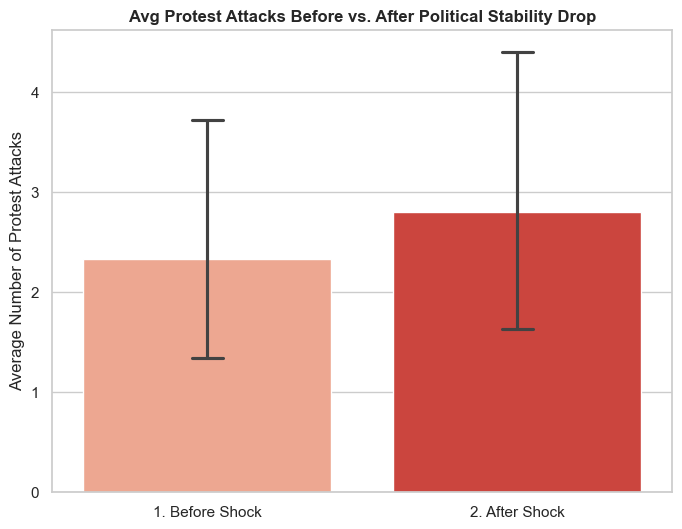

In [8]:
# 1. Aggregate to Macro level to find shocks
macro_df = df.groupby(['iso3', 'year']).agg({
    'political_stability': 'mean',
}).reset_index()

# Define a shock as a drop in stability > 0.1 from the previous year
macro_df['stability_change'] = macro_df.groupby('iso3')['political_stability'].diff()
shocks = macro_df[macro_df['stability_change'] < -0.1]

before_counts = []
after_counts = []
plot_data = []

# Collect paired data for the T-Test
for _, row in shocks.iterrows():
    country, shock_year = row['iso3'], row['year']
    
    after = df[
        (df['iso3'] == country) &
        (df['year'] == shock_year) &
        (df['motive_clean'].str.lower() == 'protest')
    ].shape[0]

    before = df[
        (df['iso3'] == country) &
        (df['year'] == shock_year - 1) &
        (df['motive_clean'].str.lower() == 'protest')
    ].shape[0]
    
    before_counts.append(before)
    after_counts.append(after)
    
    plot_data.append({'Period': '1. Before Shock', 'Count': before})
    plot_data.append({'Period': '2. After Shock', 'Count': after})

# Perform Paired T-Test (alternative='greater' because we expect an increase)
t_stat, p_value = stats.ttest_rel(after_counts, before_counts, alternative='greater')

print(f"Results for Paired T-Test (n={len(before_counts)} shocks):")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: REJECT H₀. There is a statistically significant increase in Protest attacks following a stability shock.")
else:
    print("\nConclusion: FAIL TO REJECT H₀. The increase is not statistically significant at alpha=0.05.")

# Plot H1
h1_plot_df = pd.DataFrame(plot_data)
plt.figure(figsize=(8, 6))
sns.barplot(data=h1_plot_df, x='Period', y='Count', estimator='mean', palette='Reds', capsize=.1)
plt.title('Avg Protest Attacks Before vs. After Political Stability Drop', fontweight='bold')
plt.ylabel('Average Number of Protest Attacks')
plt.xlabel('')
plt.show()

---
## Hypothesis 2: Observed vs. Expected Attack Motives (Chi-Square Statistic)

During an economic crisis, the priorities of threat actors shift. We will use a Chi-Square Test of Independence to prove that the distribution of attack motives during high inflation periods is fundamentally different from the historical baseline.

* **H₀ (Null Hypothesis):** The observed frequencies of attack motives (Financial, Protest, Sabotage, etc.) during an economic crisis follow the expected historical distribution.
* **Hₐ (Alternative Hypothesis):** The observed frequencies significantly deviate from the expected distribution during a crisis.
* **Method:** Chi-Square Statistic to measure the discrepancy between actual crisis data (Inflation > 10%) and historical baseline data.

Observed Frequencies (Contingency Table):


motive_clean,Disruption,Financial,Political-Espionage,Protest,Undetermined
Baseline (Inflation <= 10%),506,9109,718,1170,3210
Crisis (Inflation > 10%),96,148,92,701,131



Results for Chi-Square Test:
Chi-Square Statistic: 3081.9728
Degrees of Freedom:   4
P-Value:              0.0000e+00

Conclusion: REJECT H₀. The distribution of cyber attack motives during an economic crisis is fundamentally different from the historical baseline.


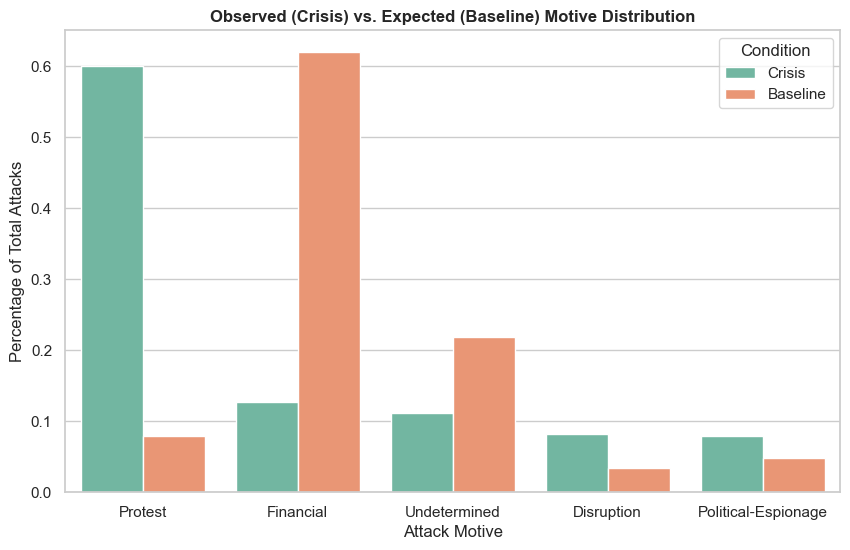

In [9]:
# Define Crisis vs Baseline
df['is_crisis'] = df['inflation_cpi'] > 10 

# Get the top 5 most common motives overall to test
top_5_motives = df['motive_clean'].value_counts().head(5).index.tolist()

# Filter data to only include these top 5 motives
filtered_df = df[df['motive_clean'].isin(top_5_motives)]

# Create a Contingency Table (Rows = Condition, Columns = Motive)
contingency_table = pd.crosstab(filtered_df['is_crisis'], filtered_df['motive_clean'])
contingency_table.index = ['Baseline (Inflation <= 10%)', 'Crisis (Inflation > 10%)']

print("Observed Frequencies (Contingency Table):")
display(contingency_table)

# Perform Chi-Square Test of Independence
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nResults for Chi-Square Test:")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom:   {dof}")
print(f"P-Value:              {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: REJECT H₀. The distribution of cyber attack motives during an economic crisis is fundamentally different from the historical baseline.")
else:
    print("\nConclusion: FAIL TO REJECT H₀. There is no significant difference in motives during a crisis.")

# Plot H2
crisis_dist = filtered_df[filtered_df['is_crisis'] == True]['motive_clean'].value_counts(normalize=True).rename('Crisis')
baseline_dist = filtered_df[filtered_df['is_crisis'] == False]['motive_clean'].value_counts(normalize=True).rename('Baseline')

combined_dist = pd.concat([crisis_dist, baseline_dist], axis=1).fillna(0)
h2_plot_df = combined_dist.reset_index().melt(id_vars='motive_clean', var_name='Condition', value_name='Frequency')
h2_plot_df.rename(columns={'motive_clean': 'Motive'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=h2_plot_df, x='Motive', y='Frequency', hue='Condition', palette='Set2')
plt.title('Observed (Crisis) vs. Expected (Baseline) Motive Distribution', fontweight='bold')
plt.ylabel('Percentage of Total Attacks')
plt.xlabel('Attack Motive')
plt.show()

---
## Hypothesis 3: Target Country Wealth by Attack Motive (One-Way ANOVA)
This test investigates whether Financially motivated actors target significantly wealthier nations (higher GDP) compared to actors driven by Protest or Political-Espionage.

* **H₀ (Null Hypothesis):** The average wealth (GDP) of a target country is the same regardless of the cyber attack's motive.
* **Hₐ (Alternative Hypothesis):** The average wealth (GDP) of a target country differs significantly based on the attack motive.
* **Method:** One-Way ANOVA (Analysis of Variance) to compare the mean GDP across the top three distinct attack motives, visualized using a log-scaled boxplot.

Groups tested: ['Financial', 'Protest', 'Political-Espionage']
Results for One-Way ANOVA:
F-Statistic: 1574.6477
P-Value:     0.0000e+00

Conclusion: REJECT H₀. There is a statistically significant difference in the wealth (GDP) of countries targeted by different hacker motives.


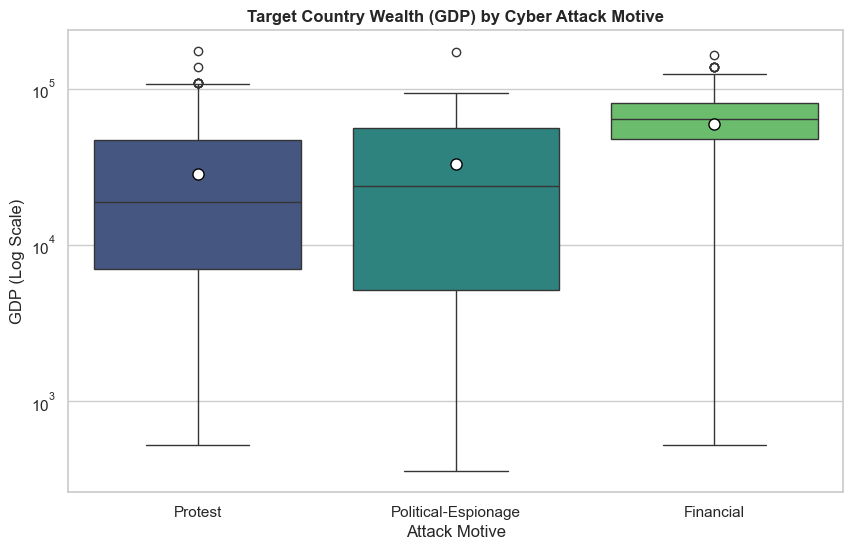

In [10]:
# Ensure GDP is numeric and drop missing values for this specific test
target_col = 'gdp_per_capita' if 'gdp_per_capita' in df.columns else 'gdp' 

h3_df = df.dropna(subset=[target_col, 'motive_clean']).copy()

# Keep only the Top 3 specific motives (Drop 'Unknown' or 'Undetermined')
valid_motives = ['Financial', 'Protest', 'Political-Espionage'] # Using the exact names from your H2 output
h3_df = h3_df[h3_df['motive_clean'].isin(valid_motives)]

# Group the data for ANOVA
groups = [group[target_col].values for name, group in h3_df.groupby('motive_clean')]

# Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"Groups tested: {valid_motives}")
print(f"Results for One-Way ANOVA:")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: REJECT H₀. There is a statistically significant difference in the wealth (GDP) of countries targeted by different hacker motives.")
else:
    print("\nConclusion: FAIL TO REJECT H₀. Target country wealth does not significantly differ by attack motive.")

# Plot H3 using a Boxplot (We use a log scale because GDP numbers are huge)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=h3_df, 
    x='motive_clean', 
    y=target_col, 
    palette='viridis',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.title('Target Country Wealth (GDP) by Cyber Attack Motive', fontweight='bold')
plt.ylabel('GDP (Log Scale)')
plt.xlabel('Attack Motive')
plt.yscale('log')
plt.show()